In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

plt.style.use('bmh')


In [2]:
mem_df = pd.read_csv('../data/symscan_memory_benchmark.csv', index_col=0)

scaling exponent: 0.995 +/- 0.014
scaling exponent: 0.832 +/- 0.037


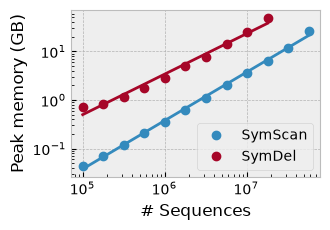

In [5]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))

for algorithm in mem_df['algorithm'].unique():
    mean = mem_df[mem_df['algorithm'] == algorithm].groupby('n_sequence')['memory_gb'].mean()
    x, y = mean.index.values, mean.values
    slope, intercept, r, p, se = scipy.stats.linregress(np.log(x), np.log(y))
    print(f'scaling exponent: {slope:.3} +/- {se:.2}')

    l, = ax.plot(x, y, 'o', label='SymScan' if algorithm == 'symscan' else 'SymDel')
    ax.plot(x, np.exp(slope * np.log(x) + intercept), '-', color=l.get_color())
ax.legend(loc='lower right')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('# Sequences')
ax.set_ylabel('Peak memory (GB)')
fig.tight_layout()

fig.savefig('figs/symscan_memory_scaling.svg')
fig.savefig('figs/symscan_memory_scaling.png', dpi=300)
fig.savefig('figs/symscan_memory_scaling.pdf')